# Stop-Loss Analysis: Static vs Time-Decaying Stops

**Context:**  
The current backtest uses `z_stop=None`. 79% of trades hit the `max_hold` time stop,
destroying -$96,899 net. Of those max_hold exits, 58% had negative gross P&L — meaning
the spread widened further and was still wide at exit. A stop-loss would have cut
these trades earlier, at a smaller loss.

**What this notebook tests (retroactively on existing trades):**

For each `max_hold` trade, reconstruct the z-score at every 15-min bar during the hold.
Then ask: *if we had exited when |z| crossed a threshold, what would P&L have been?*

**Static stop:** threshold is fixed (e.g. |z| ≥ 4.5 at any bar → exit).  
**Time-decaying stop:** threshold starts wide (`z_initial`) and tightens linearly to
`z_final` by the last bar. A position that survives longer without reverting gets
progressively less room — encoding the intuition that persistent divergence is more
likely a regime shift than a temporary fluctuation.

**Key output:** Net P&L delta vs no-stop baseline for each rule.

In [1]:
import sys
from pathlib import Path
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import datetime as dt, math, itertools
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from tqdm.auto import tqdm

from analysis.preprocessing import load_processed

SNAPSHOT       = "../results/snapshots/trades_15min_z35_zh180_zx175_84d_2022-2024.parquet"
TIMEFRAME      = "15min"
ZSCORE_WINDOW  = 5 * 26          # zscore_window_days=5, 26 bars/day
COST_BPS       = 5.0

trades_df = pl.read_parquet(SNAPSHOT)
max_hold  = trades_df.filter(pl.col('exit_reason') == 'max_hold')
print(f"Total trades: {len(trades_df):,}  |  max_hold: {len(max_hold):,}")
print(f"max_hold gross P&L: ${max_hold['gross_pnl'].sum():+,.0f}")
print(f"  of which negative (spread widened): {(max_hold['gross_pnl'] < 0).sum():,} trades")
print(f"  of which positive (partial revert): {(max_hold['gross_pnl'] > 0).sum():,} trades")

Total trades: 7,820  |  max_hold: 6,172
max_hold gross P&L: $-59,170
  of which negative (spread widened): 3,590 trades
  of which positive (partial revert): 2,582 trades


In [2]:
# ── Load price cache (once) ───────────────────────────────────────────────
all_tickers = set(trades_df['ticker_a']) | set(trades_df['ticker_b'])
all_dates   = trades_df['entry_time'].dt.date().unique().sort().to_list()
data_start  = all_dates[0]  - dt.timedelta(days=50)   # enough for zscore lookback
data_end    = all_dates[-1]

print(f"Loading {len(all_tickers)} tickers ({data_start} → {data_end}) …")
price_cache: dict[str, dict] = {}
for ticker in tqdm(sorted(all_tickers), desc='Prices'):
    try:
        df = load_processed(ticker, TIMEFRAME,
                            start_date=str(data_start), end_date=str(data_end))
        if df is not None and len(df) > 0:
            price_cache[ticker] = {
                r['timestamp']: r['close']
                for r in df.select(['timestamp','close']).iter_rows(named=True)
            }
    except FileNotFoundError:
        pass
print(f"Loaded {len(price_cache)} tickers.")

Loading 199 tickers (2022-05-22 → 2024-07-01) …


Prices:   0%|          | 0/199 [00:00<?, ?it/s]

Loaded 199 tickers.


In [3]:
def get_trade_trajectory(
    ta: str, tb: str, hedge_ratio: float,
    direction: int, shares_a: float, shares_b: float,
    ep_a: float, ep_b: float,
    entry_time: dt.datetime, exit_time: dt.datetime,
    price_cache: dict,
    zscore_window: int,
) -> tuple[np.ndarray, np.ndarray] | None:
    """
    Returns (z_scores, gross_pnls) arrays with one value per 15-min bar
    from entry_time to exit_time inclusive.

    z_scores[b]:    z-score of the log-spread at bar b (using rolling lookback)
    gross_pnls[b]:  hypothetical gross P&L if exited at bar b's close price
    Returns None if prices unavailable.
    """
    ca = price_cache.get(ta)
    cb = price_cache.get(tb)
    if ca is None or cb is None:
        return None

    shared = sorted(set(ca) & set(cb))
    if len(shared) < zscore_window + 1:
        return None

    # Split into pre-hold (for z-score lookback) and hold bars
    pre  = [t for t in shared if t <  entry_time]
    hold = [t for t in shared if entry_time <= t <= exit_time]

    if len(pre) < zscore_window or len(hold) == 0:
        return None

    all_ts = pre[-zscore_window:] + hold
    ls = np.array([
        math.log(ca[t]) - hedge_ratio * math.log(cb[t])
        for t in all_ts
        if ca[t] > 0 and cb[t] > 0
    ])
    if len(ls) < zscore_window + len(hold):
        return None

    z_scores  = np.empty(len(hold))
    gross_arr = np.empty(len(hold))

    for i, t in enumerate(hold):
        idx = zscore_window + i
        win = ls[idx - zscore_window : idx]
        mu, sd = win.mean(), win.std(ddof=1)
        z_scores[i] = (ls[idx] - mu) / sd if sd > 1e-10 else 0.0
        gross_arr[i] = direction * (
            shares_a * (ca[t] - ep_a) - shares_b * (cb[t] - ep_b)
        )

    return z_scores, gross_arr


# ── Reconstruct trajectories for all max_hold trades ──────────────────────
trajectories = []   # list of (z_scores, gross_pnls, actual_gross, transaction_cost)
skipped = 0

for row in tqdm(max_hold.iter_rows(named=True), total=len(max_hold),
                desc='Trajectories'):
    result = get_trade_trajectory(
        ta=row['ticker_a'], tb=row['ticker_b'],
        hedge_ratio=row['shares_b'] / row['shares_a'],
        direction=row['direction'],
        shares_a=row['shares_a'], shares_b=row['shares_b'],
        ep_a=row['entry_price_a'], ep_b=row['entry_price_b'],
        entry_time=row['entry_time'], exit_time=row['exit_time'],
        price_cache=price_cache, zscore_window=ZSCORE_WINDOW,
    )
    if result is None:
        skipped += 1
    else:
        trajectories.append((*result, row['gross_pnl'], row['transaction_cost']))

print(f"Trajectories: {len(trajectories):,} computed, {skipped} skipped")

Trajectories:   0%|          | 0/6172 [00:00<?, ?it/s]

Trajectories: 6,172 computed, 0 skipped


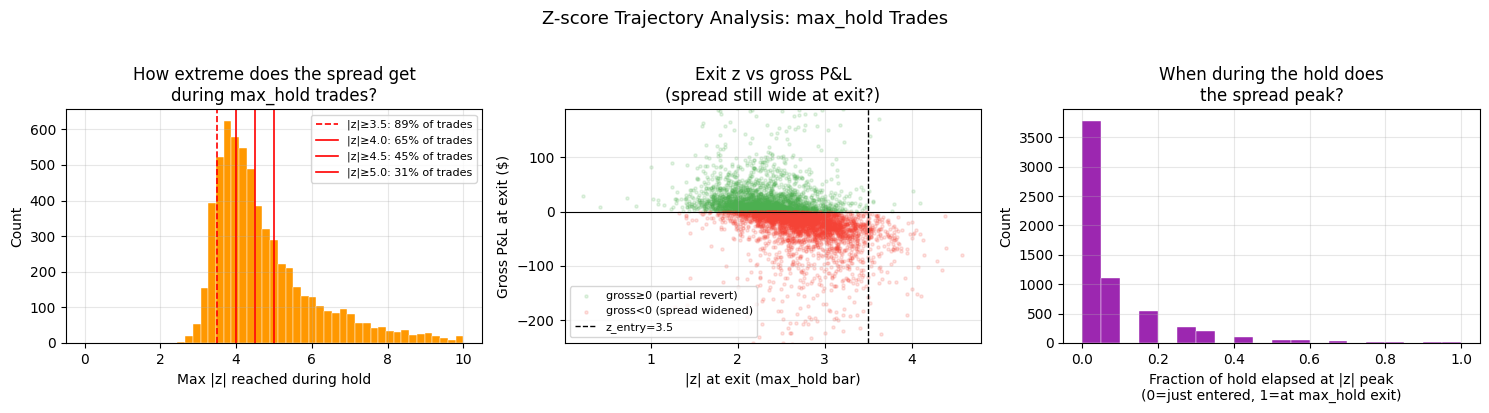

Trades where max |z| ≥ 4.0: 4,026 (65.2%)
Trades where max |z| ≥ 4.5: 2,760 (44.7%)
Trades where max |z| ≥ 5.0: 1,923 (31.2%)

Peak |z| occurs in first half of hold: 97.2%
Peak |z| occurs in last bar:           0.1%


In [4]:
# ── Distribution of max |z| reached during each max_hold trade ───────────
max_abs_z = np.array([np.max(np.abs(z)) for z, *_ in trajectories])
final_z   = np.array([z[-1]             for z, *_ in trajectories])
actual_gross = np.array([g for _, __, g, ___ in trajectories])
costs        = np.array([c for _, __, ___, c in trajectories])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 1: distribution of max |z| during hold
ax = axes[0]
bins = np.linspace(0, 10, 50)
ax.hist(max_abs_z, bins=bins, color='#FF9800', edgecolor='white', linewidth=0.3)
for zs, ls in [(3.5,'--'), (4.0,'-'), (4.5,'-'), (5.0,'-')]:
    pct = (max_abs_z >= zs).mean() * 100
    ax.axvline(zs, color='red', linewidth=1.2, linestyle=ls,
               label=f'|z|≥{zs}: {pct:.0f}% of trades')
ax.set_xlabel('Max |z| reached during hold')
ax.set_ylabel('Count')
ax.set_title('How extreme does the spread get\nduring max_hold trades?')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Panel 2: final |z| at max_hold exit vs actual gross P&L
ax = axes[1]
pos_mask = actual_gross >= 0
neg_mask = actual_gross <  0
ax.scatter(np.abs(final_z[pos_mask]), actual_gross[pos_mask],
           alpha=0.15, s=5, color='#4CAF50', label='gross≥0 (partial revert)', rasterized=True)
ax.scatter(np.abs(final_z[neg_mask]), actual_gross[neg_mask],
           alpha=0.15, s=5, color='#F44336', label='gross<0 (spread widened)', rasterized=True)
ax.axvline(3.5, color='black', linewidth=1.0, linestyle='--', label='z_entry=3.5')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('|z| at exit (max_hold bar)')
ax.set_ylabel('Gross P&L at exit ($)')
ax.set_ylim(np.percentile(actual_gross,1), np.percentile(actual_gross,99))
ax.set_title('Exit z vs gross P&L\n(spread still wide at exit?)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Panel 3: at what bar during the hold does |z| peak?
ax = axes[2]
peak_bars = np.array([int(np.argmax(np.abs(z))) for z, *_ in trajectories])
n_bars_arr = np.array([len(z) for z, *_ in trajectories])
peak_frac  = peak_bars / (n_bars_arr - 1)   # 0=entry, 1=exit
ax.hist(peak_frac, bins=20, color='#9C27B0', edgecolor='white', linewidth=0.3)
ax.set_xlabel('Fraction of hold elapsed at |z| peak\n(0=just entered, 1=at max_hold exit)')
ax.set_ylabel('Count')
ax.set_title('When during the hold does\nthe spread peak?')
ax.grid(alpha=0.3)

plt.suptitle('Z-score Trajectory Analysis: max_hold Trades', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Trades where max |z| ≥ 4.0: {(max_abs_z >= 4.0).sum():,} ({(max_abs_z >= 4.0).mean():.1%})")
print(f"Trades where max |z| ≥ 4.5: {(max_abs_z >= 4.5).sum():,} ({(max_abs_z >= 4.5).mean():.1%})")
print(f"Trades where max |z| ≥ 5.0: {(max_abs_z >= 5.0).sum():,} ({(max_abs_z >= 5.0).mean():.1%})")
print(f"\nPeak |z| occurs in first half of hold: {(peak_frac < 0.5).mean():.1%}")
print(f"Peak |z| occurs in last bar:           {(peak_bars == (n_bars_arr-1)).mean():.1%}")

In [5]:
def apply_stop_rule(
    trajectories: list,
    z_initial: float,
    z_final: float | None = None,   # None → static stop at z_initial
) -> dict:
    """
    Retroactively apply a stopping rule to all max_hold trajectories.

    Static stop:  z_stop = z_initial at every bar.
    Decaying stop: z_stop(b) = z_initial - (z_initial - z_final) * b / (N-1)
                   where N = number of hold bars, b = bar index (0=entry).

    For each trade:
      - If |z[b]| >= z_stop(b) at bar b: hypothetical exit at bar b.
        gross_pnl = gross_arr[b];  net_pnl = gross_arr[b] - transaction_cost.
      - Otherwise: outcome unchanged (trade completes at max_hold).

    Returns dict with aggregate stats.
    """
    n_stopped = 0
    delta_gross  = 0.0   # positive = saved losses
    n_winners_cut = 0    # trade would have been a gross winner but was stopped
    n_losers_saved = 0   # trade had negative gross, stopped earlier (at lesser loss or profit)
    stop_bar_fracs = []

    for z_arr, gross_arr, actual_gross, cost in trajectories:
        N = len(z_arr)
        stopped_at = None

        for b in range(N):
            if z_final is None:
                threshold = z_initial
            else:
                threshold = z_initial - (z_initial - z_final) * b / max(N - 1, 1)

            if abs(z_arr[b]) >= threshold:
                stopped_at = b
                break

        if stopped_at is not None:
            stop_gross = gross_arr[stopped_at]
            n_stopped += 1
            delta_gross += stop_gross - actual_gross  # negative = we left money on table
            stop_bar_fracs.append(stopped_at / max(N - 1, 1))
            if actual_gross >= 0:
                n_winners_cut += 1
            else:
                n_losers_saved += 1

    total = len(trajectories)
    return {
        'z_initial':     z_initial,
        'z_final':       z_final if z_final is not None else z_initial,
        'n_stopped':     n_stopped,
        'stop_pct':      n_stopped / total * 100,
        'delta_gross':   delta_gross,   # total gross P&L change across all trades
        'n_winners_cut': n_winners_cut,
        'n_losers_saved':n_losers_saved,
        'avg_stop_frac': float(np.mean(stop_bar_fracs)) if stop_bar_fracs else float('nan'),
    }

print("apply_stop_rule() defined.")

apply_stop_rule() defined.


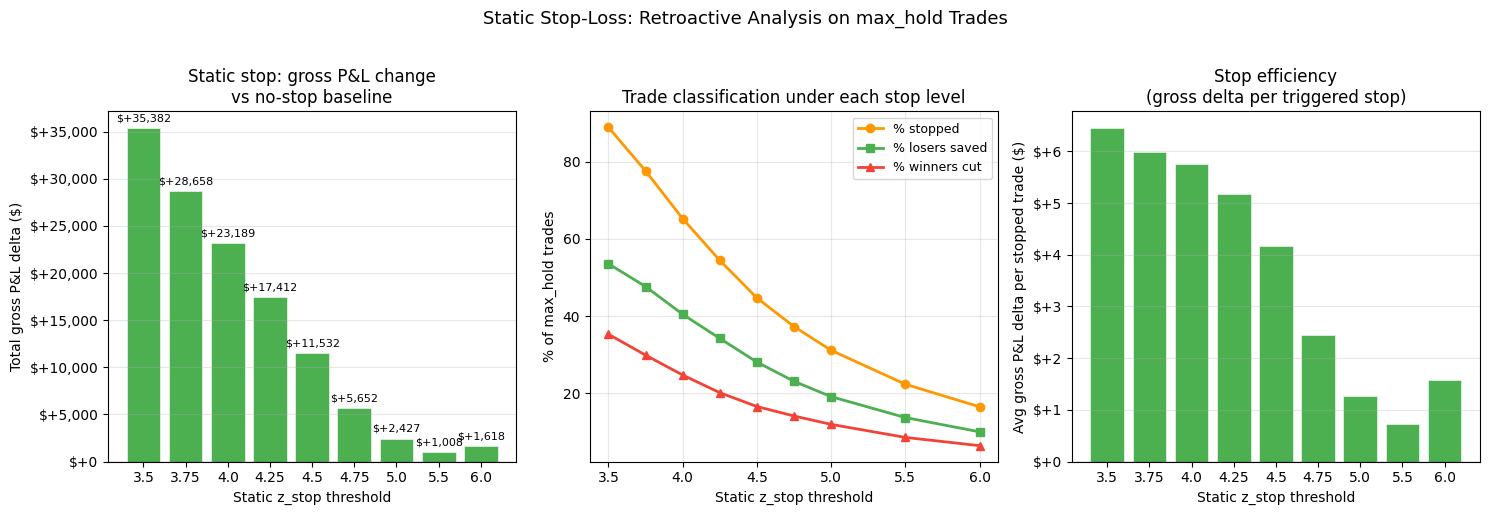

 z_stop   stopped%   delta_gross   losers_saved   winners_cut   avg_frac
───────────────────────────────────────────────────────────────────────────
    3.5      88.9%  $   +35,382         3,305        2,180       0.01
   3.75      77.6%  $   +28,658         2,942        1,846       0.02
    4.0      65.2%  $   +23,189         2,498        1,528       0.02
   4.25      54.4%  $   +17,412         2,113        1,246       0.02
    4.5      44.7%  $   +11,532         1,735        1,025       0.02
   4.75      37.3%  $    +5,652         1,428          874       0.02
    5.0      31.2%  $    +2,427         1,183          740       0.02
    5.5      22.4%  $    +1,008           849          532       0.01
    6.0      16.5%  $    +1,618           621          400       0.01


In [6]:
# ── Static stop: sweep z_stop from 3.5 to 6.0 ────────────────────────────
static_levels = [3.5, 3.75, 4.0, 4.25, 4.5, 4.75, 5.0, 5.5, 6.0]
static_results = [apply_stop_rule(trajectories, z) for z in static_levels]

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

z_vals    = [r['z_initial'] for r in static_results]
deltas    = [r['delta_gross'] for r in static_results]
stop_pcts = [r['stop_pct'] for r in static_results]
wc_pcts   = [r['n_winners_cut'] / len(trajectories) * 100 for r in static_results]
ls_pcts   = [r['n_losers_saved'] / len(trajectories) * 100 for r in static_results]

ax = axes[0]
colors = ['#4CAF50' if d > 0 else '#F44336' for d in deltas]
bars = ax.bar([str(z) for z in z_vals], deltas, color=colors,
               edgecolor='white', linewidth=0.4)
ax.axhline(0, color='black', linewidth=0.8)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:+,.0f}'))
ax.set_xlabel('Static z_stop threshold')
ax.set_ylabel('Total gross P&L delta ($)')
ax.set_title('Static stop: gross P&L change\nvs no-stop baseline')
ax.grid(axis='y', alpha=0.3)
for bar, d in zip(bars, deltas):
    ax.text(bar.get_x() + bar.get_width()/2,
            d + (500 if d >= 0 else -500),
            f'${d:+,.0f}', ha='center', fontsize=8,
            va='bottom' if d >= 0 else 'top')

ax = axes[1]
ax.plot(z_vals, stop_pcts, marker='o', color='#FF9800', linewidth=2, label='% stopped')
ax.plot(z_vals, ls_pcts,   marker='s', color='#4CAF50', linewidth=2, label='% losers saved')
ax.plot(z_vals, wc_pcts,   marker='^', color='#F44336', linewidth=2, label='% winners cut')
ax.set_xlabel('Static z_stop threshold')
ax.set_ylabel('% of max_hold trades')
ax.set_title('Trade classification under each stop level')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax = axes[2]
# Efficiency: delta_gross per stopped trade
eff = [r['delta_gross'] / r['n_stopped'] if r['n_stopped'] > 0 else 0
       for r in static_results]
ax.bar([str(z) for z in z_vals], eff,
       color=['#4CAF50' if e > 0 else '#F44336' for e in eff],
       edgecolor='white', linewidth=0.4)
ax.axhline(0, color='black', linewidth=0.8)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:+,.0f}'))
ax.set_xlabel('Static z_stop threshold')
ax.set_ylabel('Avg gross P&L delta per stopped trade ($)')
ax.set_title('Stop efficiency\n(gross delta per triggered stop)')
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Static Stop-Loss: Retroactive Analysis on max_hold Trades',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"{'z_stop':>7}  {'stopped%':>9}  {'delta_gross':>12}  {'losers_saved':>13}  {'winners_cut':>12}  {'avg_frac':>9}")
print('─' * 75)
for r in static_results:
    print(f"  {r['z_initial']:>5}  {r['stop_pct']:>8.1f}%  "
          f"${r['delta_gross']:>+10,.0f}  "
          f"{r['n_losers_saved']:>12,}  {r['n_winners_cut']:>11,}  "
          f"{r['avg_stop_frac']:>9.2f}")

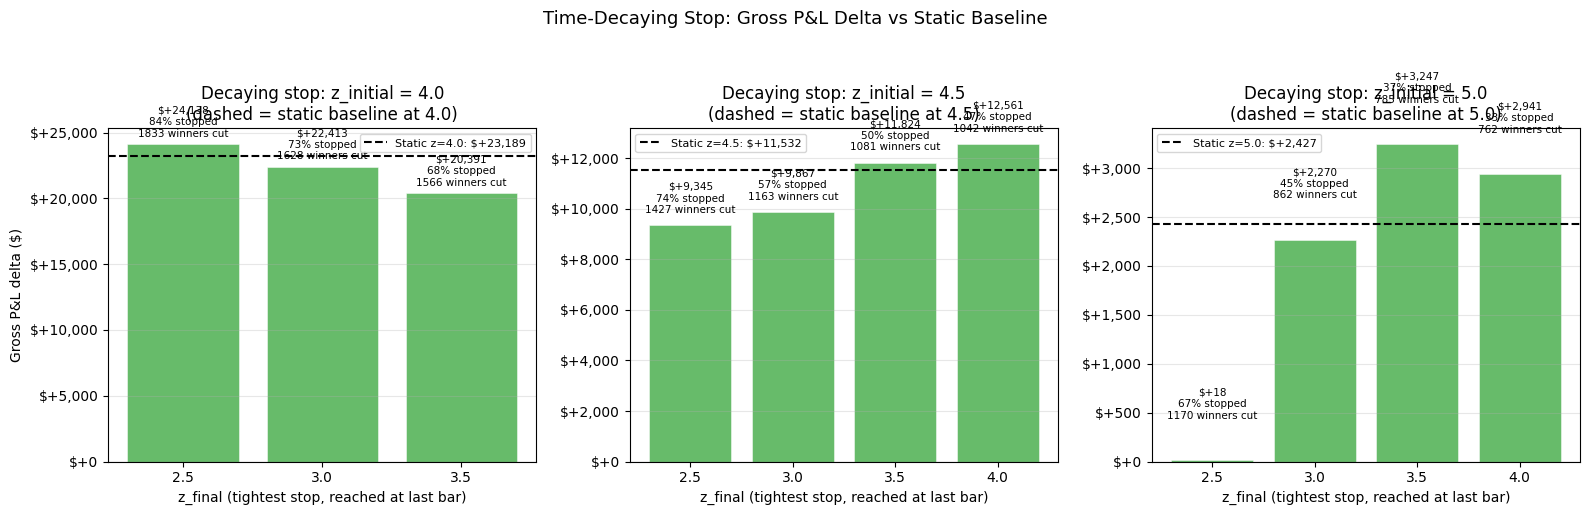

In [7]:
# ── Time-decaying stop: grid over (z_initial, z_final) ───────────────────
z_initials = [4.0, 4.5, 5.0]
z_finals   = [2.5, 3.0, 3.5, 4.0]   # z_final < z_initial for decay

decay_results = []
for zi, zf in itertools.product(z_initials, z_finals):
    if zf >= zi:
        continue   # no decay; skip
    r = apply_stop_rule(trajectories, z_initial=zi, z_final=zf)
    decay_results.append(r)

# Also run static equivalents for comparison
static_comp = {zi: apply_stop_rule(trajectories, zi) for zi in z_initials}

# ── Heatmap: delta_gross for each (z_initial, z_final) ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, zi in zip(axes, z_initials):
    sub = [r for r in decay_results if r['z_initial'] == zi]
    zf_vals  = [r['z_final']    for r in sub]
    dg_vals  = [r['delta_gross'] for r in sub]
    sp_vals  = [r['stop_pct']   for r in sub]
    wc_vals  = [r['n_winners_cut'] for r in sub]

    # Bar chart per z_final
    colors = ['#4CAF50' if d > 0 else '#F44336' for d in dg_vals]
    bars = ax.bar([str(zf) for zf in zf_vals], dg_vals,
                  color=colors, alpha=0.85, edgecolor='white', linewidth=0.4)

    # Compare to static stop at same z_initial
    static_dg = static_comp[zi]['delta_gross']
    ax.axhline(static_dg, color='black', linewidth=1.5, linestyle='--',
               label=f'Static z={zi}: ${static_dg:+,.0f}')
    ax.axhline(0, color='grey', linewidth=0.8)

    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:+,.0f}'))
    ax.set_xlabel('z_final (tightest stop, reached at last bar)')
    ax.set_ylabel('Gross P&L delta ($)' if ax == axes[0] else '')
    ax.set_title(f'Decaying stop: z_initial = {zi}\n(dashed = static baseline at {zi})')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

    for bar, dg, sp, wc in zip(bars, dg_vals, sp_vals, wc_vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                dg + (400 if dg >= 0 else -400),
                f'${dg:+,.0f}\n{sp:.0f}% stopped\n{wc} winners cut',
                ha='center', va='bottom' if dg >= 0 else 'top',
                fontsize=7.5)

plt.suptitle('Time-Decaying Stop: Gross P&L Delta vs Static Baseline',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [8]:
# ── Compare every stopping rule side-by-side ─────────────────────────────
all_results = (
    [{'label': f'static {r["z_initial"]}', **r} for r in static_results]
    + [{'label': f'decay {r["z_initial"]}→{r["z_final"]}', **r} for r in decay_results]
)
all_results.sort(key=lambda r: r['delta_gross'], reverse=True)

print('All stopping rules ranked by gross P&L improvement:')
print(f"  {'Rule':>22}  {'stopped%':>9}  {'delta_gross':>12}  {'winners_cut':>12}  {'losers_saved':>13}")
print('  ' + '─' * 75)
for r in all_results[:15]:   # top 15
    print(f"  {r['label']:>22}  {r['stop_pct']:>8.1f}%  "
          f"${r['delta_gross']:>+10,.0f}  "
          f"{r['n_winners_cut']:>11,}  {r['n_losers_saved']:>12,}")

# ── The best rule: show how it changes aggregate P&L ─────────────────────
best = all_results[0]
print()
print('═' * 55)
print(f'BEST RULE: {best["label"]}')
print('═' * 55)
baseline_gross = max_hold['gross_pnl'].sum()
baseline_net   = max_hold['net_pnl'].sum()
print(f'  max_hold gross P&L (baseline): ${baseline_gross:+,.0f}')
print(f'  max_hold gross P&L (w/ stop):  ${baseline_gross + best["delta_gross"]:+,.0f}')
print(f'  Gross improvement:              ${best["delta_gross"]:+,.0f}')
print(f'  Net improvement (same cost):    ${best["delta_gross"]:+,.0f}  (cost unchanged)')
print()
print(f'  Trades stopped early:  {best["n_stopped"]:,} ({best["stop_pct"]:.1f}%)')
print(f'  Losers saved early:    {best["n_losers_saved"]:,}')
print(f'  Winners cut early:     {best["n_winners_cut"]:,}')
print(f'  Avg exit timing:       {best["avg_stop_frac"]:.0%} through hold window')
print()

# Impact on overall portfolio P&L
total_net = trades_df['net_pnl'].sum()
new_total = total_net + best['delta_gross']
print(f'  Portfolio total net P&L (current):  ${total_net:+,.0f}')
print(f'  Portfolio total net P&L (w/ stop):  ${new_total:+,.0f}')

All stopping rules ranked by gross P&L improvement:
                    Rule   stopped%   delta_gross   winners_cut   losers_saved
  ───────────────────────────────────────────────────────────────────────────
              static 3.5      88.9%  $   +35,382        2,180         3,305
             static 3.75      77.6%  $   +28,658        1,846         2,942
           decay 4.0→2.5      83.7%  $   +24,138        1,833         3,332
              static 4.0      65.2%  $   +23,189        1,528         2,498
           decay 4.0→3.0      72.9%  $   +22,413        1,628         2,873
           decay 4.0→3.5      68.1%  $   +20,391        1,566         2,636
             static 4.25      54.4%  $   +17,412        1,246         2,113
           decay 4.5→4.0      46.7%  $   +12,561        1,042         1,838
           decay 4.5→3.5      50.0%  $   +11,824        1,081         2,002
              static 4.5      44.7%  $   +11,532        1,025         1,735
           decay 4.5→3.0      5

Case counts:
  stopped by decay only: 0
  stopped by both: 5,392
  not stopped: 780


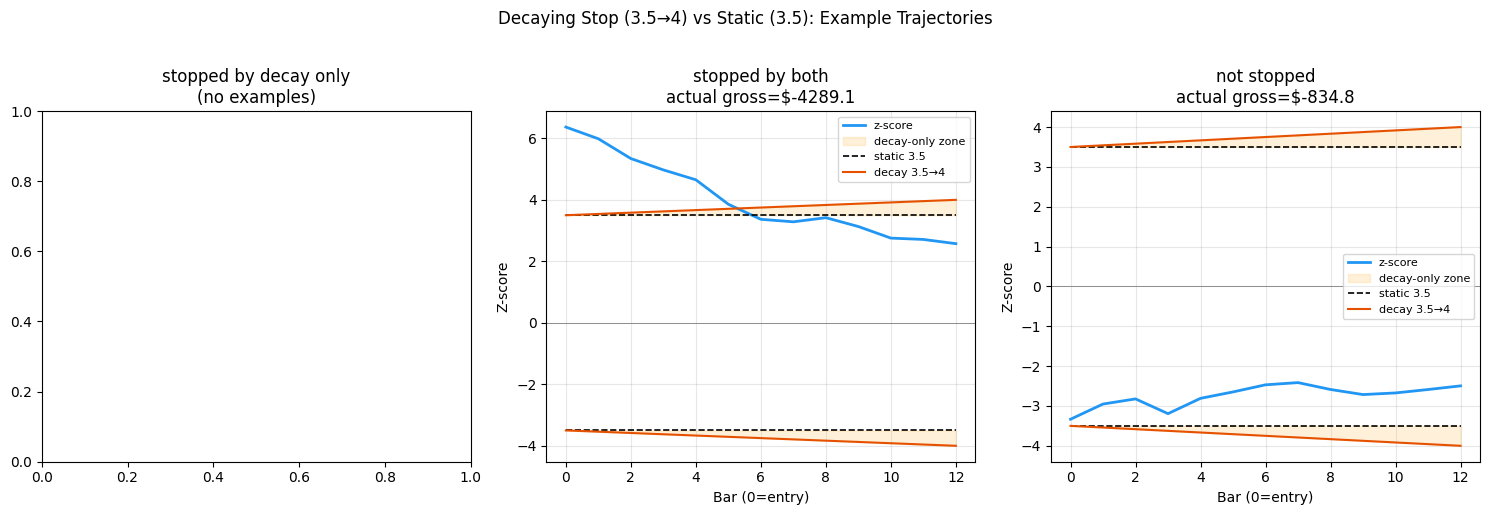

In [12]:
# ── Visualise the decaying threshold vs z trajectory for a sample of trades
# Show 3 cases: (1) trade stopped by decaying but not static,
#               (2) trade stopped by both,
#               (3) trade not stopped by either

best_zi = best['z_initial']
best_zf = 4 # best['z_final']

cases = {'stopped by decay only': [], 'stopped by both': [], 'not stopped': []}

for idx, (z_arr, gross_arr, actual_gross, cost) in enumerate(trajectories):
    N = len(z_arr)
    # Check static
    static_stop = next((b for b in range(N) if abs(z_arr[b]) >= best_zi), None)
    # Check decaying
    decay_stop  = next(
        (b for b in range(N)
         if abs(z_arr[b]) >= best_zi - (best_zi - best_zf) * b / max(N-1, 1)),
        None
    )
    if decay_stop is not None and static_stop is None:
        cases['stopped by decay only'].append(idx)
    elif decay_stop is not None and static_stop is not None:
        cases['stopped by both'].append(idx)
    else:
        cases['not stopped'].append(idx)

print('Case counts:')
for k, v in cases.items():
    print(f'  {k}: {len(v):,}')

# Plot one example from each case
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (case_name, idxs) in zip(axes, cases.items()):
    if not idxs:
        ax.set_title(f'{case_name}\n(no examples)')
        continue
    # Pick the trade with the most negative actual gross (most illustrative)
    chosen = min(idxs, key=lambda i: trajectories[i][2])
    z_arr, gross_arr, actual_gross, cost = trajectories[chosen]
    N   = len(z_arr)
    bars = range(N)

    # Thresholds
    static_thresh  = [best_zi] * N
    decay_thresh   = [best_zi - (best_zi - best_zf) * b / max(N-1,1) for b in bars]
    neg_static     = [-t for t in static_thresh]
    neg_decay      = [-t for t in decay_thresh]

    ax.plot(bars, z_arr, color='#2196F3', linewidth=2, label='z-score')
    ax.fill_between(bars, static_thresh, decay_thresh,
                    alpha=0.15, color='orange', label='decay-only zone')
    ax.fill_between(bars, neg_decay, neg_static,
                    alpha=0.15, color='orange')
    ax.plot(bars, static_thresh, color='black', linewidth=1.2,
            linestyle='--', label=f'static {best_zi}')
    ax.plot(bars, neg_static,  color='black', linewidth=1.2, linestyle='--')
    ax.plot(bars, decay_thresh, color='#E65100', linewidth=1.5,
            label=f'decay {best_zi}→{best_zf}')
    ax.plot(bars, neg_decay,   color='#E65100', linewidth=1.5)
    ax.axhline(0, color='grey', linewidth=0.6)

    ax.set_xlabel('Bar (0=entry)')
    ax.set_ylabel('Z-score')
    ax.set_title(f'{case_name}\nactual gross=${actual_gross:+.1f}')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle(f'Decaying Stop ({best_zi}→{best_zf}) vs Static ({best_zi}): Example Trajectories',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
## Interpretation guide

### If the time-decaying stop beats the static stop at same z_initial
The tightening threshold is adding value by catching trades where z drifts just
below the static level for many bars before breaching it late. This validates
the theory: a position that has been wide for a long time should be treated
more harshly.

### If the static stop dominates
Most triggering happens early (the peak z panel shows this). The decay curve
adds complexity without benefit — a flat stop at the right level is sufficient.
In this case, just pick the static level with the best gross delta / winners_cut ratio.

### If neither stop helps much (small delta_gross)
Most max_hold trades never become extreme enough to trigger any reasonable
stop (|z| stays in 3.5–4.0 range throughout). The problem is not runaway
losers but many small losses, which a stop cannot fix — the fix would need to
address entry quality (Option 1: raise z_entry) or exit patience (Option 3:
lower z_exit).